<a href="https://colab.research.google.com/github/lydiadipaola/nhanes-undiagnosed-diabetes-ml/blob/main/NHANES_Undiagnosed_Diabetes_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Undiagnosed Diabetes Using Machine Learning

## Research Question

Can routinely collected demographic, socioeconomic, behavioral, and anthropometric characteristics identify adults at elevated risk of undiagnosed diabetes without using laboratory measurements as predictors?

## Study Overview

This project uses data from the **CDC National Health and Nutrition Examination Survey (NHANES) 2017–March 2020 pre-pandemic dataset** to develop and evaluate machine learning models for identifying adults with laboratory-defined elevated HbA1c who reported no prior diagnosis of diabetes.

HbA1c was used **only to define the outcome** and was excluded from the model predictors to prevent target leakage.

Three supervised learning approaches were evaluated:

- Logistic Regression
- Random Forest
- XGBoost

Model performance was assessed using **ROC-AUC, Precision-Recall AUC (PR-AUC), and Brier score**. Because the outcome is relatively rare, particular emphasis was placed on precision-recall performance and probability calibration.

## Outcome Definition

The outcome was defined as:

**HbA1c ≥ 6.5% AND no self-reported prior diabetes diagnosis**

This represents laboratory-defined elevated HbA1c consistent with diabetes among participants without a reported diabetes diagnosis. It should be interpreted as a **risk-screening outcome rather than a clinical diagnosis**, since a single laboratory measurement does not establish a clinical diagnosis.

## Predictors

The model uses information that could be available without laboratory testing:

- Age
- Sex
- Race/ethnicity
- Education
- Income-to-poverty ratio
- Body mass index (BMI)
- Waist circumference
- Smoking history
- Vigorous physical activity
- Moderate physical activity

## Goal

The goal is to demonstrate an interpretable machine learning workflow for a public-health screening problem while emphasizing appropriate handling of **class imbalance, model evaluation, probability calibration, and prevention of target leakage**.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    confusion_matrix
)

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

In [27]:
BASE = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/"

files = {
    "demo": "P_DEMO.XPT",
    "bmi": "P_BMX.XPT",
    "diabetes": "P_DIQ.XPT",
    "smoking": "P_SMQ.XPT",
    "activity": "P_PAQ.XPT",
    "glyco": "P_GHB.XPT"
}

dfs = {}

for name, file in files.items():
    dfs[name] = pd.read_sas(BASE + file, format="xport")
    print(f"{name}: {dfs[name].shape}")

demo: (15560, 29)
bmi: (14300, 22)
diabetes: (14986, 28)
smoking: (11137, 16)
activity: (9693, 17)
glyco: (10409, 2)


In [28]:
demo = dfs["demo"][[
    "SEQN",
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "INDFMPIR",
    "SDMVSTRA",
    "SDMVPSU"
]]

bmi = dfs["bmi"][[
    "SEQN",
    "BMXBMI",
    "BMXWAIST"
]]

diabetes = dfs["diabetes"][[
    "SEQN",
    "DIQ010"
]]

smoking = dfs["smoking"][[
    "SEQN",
    "SMQ020"
]]

activity = dfs["activity"][[
    "SEQN",
    "PAQ605",
    "PAQ620"
]]

glyco = dfs["glyco"][[
    "SEQN",
    "LBXGH"
]]

df = (
    demo
    .merge(bmi, on="SEQN", how="inner")
    .merge(diabetes, on="SEQN", how="inner")
    .merge(smoking, on="SEQN", how="left")
    .merge(activity, on="SEQN", how="left")
    .merge(glyco, on="SEQN", how="inner")
)

print("Merged dataset:", df.shape)

Merged dataset: (10409, 15)


In [29]:
df = df[df["RIDAGEYR"] >= 18].copy()

df = df.dropna(
    subset=["LBXGH", "DIQ010"]
)

# Laboratory-defined elevated HbA1c
# among adults without self-reported diabetes
df["undiagnosed_diabetes"] = (
    (df["LBXGH"] >= 6.5) &
    (df["DIQ010"] == 2)
).astype(int)

print("Adults:", len(df))
print("\nOutcome counts:")
print(df["undiagnosed_diabetes"].value_counts())

print("\nOutcome prevalence:")
print(f"{df['undiagnosed_diabetes'].mean():.2%}")

Adults: 8464

Outcome counts:
undiagnosed_diabetes
0    8236
1     228
Name: count, dtype: int64

Outcome prevalence:
2.69%


In [30]:
df = df.rename(columns={
    "RIDAGEYR": "age",
    "RIAGENDR": "sex",
    "RIDRETH3": "race_ethnicity",
    "DMDEDUC2": "education",
    "INDFMPIR": "income_ratio",
    "BMXBMI": "bmi",
    "BMXWAIST": "waist",
    "SMQ020": "ever_smoked",
    "PAQ605": "vigorous_activity",
    "PAQ620": "moderate_activity"
})

features = [
    "age",
    "sex",
    "race_ethnicity",
    "education",
    "income_ratio",
    "bmi",
    "waist",
    "ever_smoked",
    "vigorous_activity",
    "moderate_activity"
]

model_df = df[
    features + ["undiagnosed_diabetes"]
].copy()

print("Model dataset:", model_df.shape)

Model dataset: (8464, 11)


In [31]:
X = model_df[features]
y = model_df["undiagnosed_diabetes"]

numeric_features = [
    "age",
    "income_ratio",
    "bmi",
    "waist"
]

categorical_features = [
    "sex",
    "race_ethnicity",
    "education",
    "ever_smoked",
    "vigorous_activity",
    "moderate_activity"
]

preprocessor = ColumnTransformer([
    (
        "numeric",
        SimpleImputer(strategy="median"),
        numeric_features
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)
print("Positive cases in test:", y_test.sum())

Training: (6771, 10)
Testing: (1693, 10)
Positive cases in test: 46


In [32]:
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("scale", StandardScaler(with_mean=False)),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric="logloss",
            random_state=42
        ))
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


In [33]:
results = []

for name, model in models.items():

    probability = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, probability),
        "PR-AUC": average_precision_score(y_test, probability),
        "Brier Score": brier_score_loss(y_test, probability)
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(3))

,Model,ROC-AUC,PR-AUC,Brier Score
0,Logistic Regression,0.743,0.070,0.201
1,XGBoost,0.718,0.063,0.132
2,Random Forest,0.694,0.054,0.044


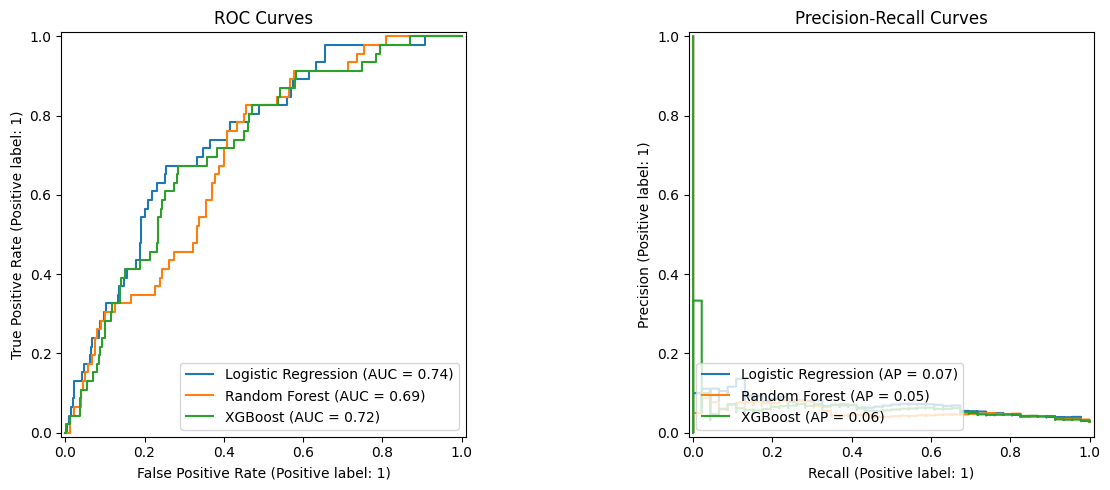

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, model in models.items():

    probability = model.predict_proba(X_test)[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        probability,
        name=name,
        ax=axes[0]
    )

    PrecisionRecallDisplay.from_predictions(
        y_test,
        probability,
        name=name,
        ax=axes[1]
    )

axes[0].set_title("ROC Curves")
axes[1].set_title("Precision-Recall Curves")

plt.tight_layout()
plt.show()

In [35]:
best_model = models["Logistic Regression"]
probability = best_model.predict_proba(X_test)[:, 1]

rng = np.random.RandomState(42)
bootstrap_auc = []

for _ in range(2000):

    indices = rng.randint(
        0,
        len(y_test),
        len(y_test)
    )

    y_sample = y_test.iloc[indices]
    p_sample = probability[indices]

    if y_sample.nunique() < 2:
        continue

    bootstrap_auc.append(
        roc_auc_score(
            y_sample,
            p_sample
        )
    )

auc = roc_auc_score(
    y_test,
    probability
)

lower, upper = np.percentile(
    bootstrap_auc,
    [2.5, 97.5]
)

print(f"ROC-AUC: {auc:.3f}")
print(f"95% Bootstrap CI: {lower:.3f} – {upper:.3f}")

ROC-AUC: 0.743
95% Bootstrap CI: 0.676 – 0.805


In [36]:
base_lr = Pipeline([
    ("prep", preprocessor),
    ("scale", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

calibrated_lr = CalibratedClassifierCV(
    base_lr,
    method="sigmoid",
    cv=5
)

calibrated_lr.fit(X_train, y_train)

calibrated_prob = calibrated_lr.predict_proba(
    X_test
)[:, 1]

print(
    f"ROC-AUC: "
    f"{roc_auc_score(y_test, calibrated_prob):.3f}"
)

print(
    f"PR-AUC: "
    f"{average_precision_score(y_test, calibrated_prob):.3f}"
)

print(
    f"Brier Score: "
    f"{brier_score_loss(y_test, calibrated_prob):.3f}"
)

ROC-AUC: 0.742
PR-AUC: 0.069
Brier Score: 0.026


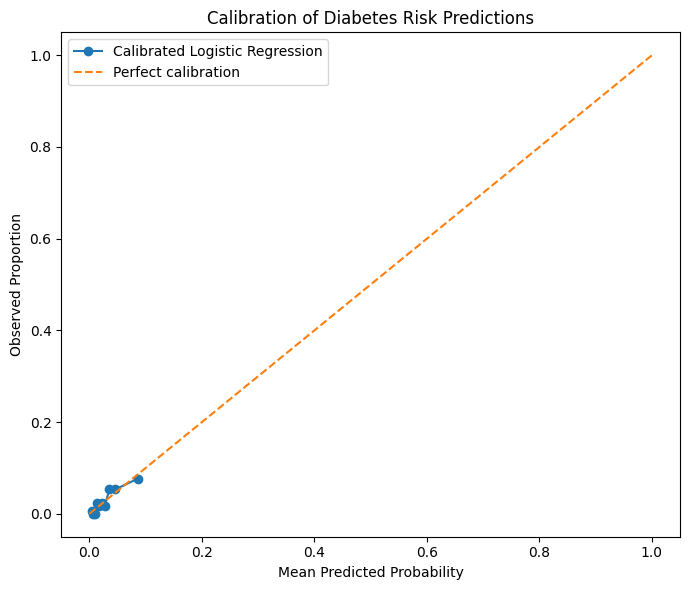

In [37]:
prob_true, prob_pred = calibration_curve(
    y_test,
    calibrated_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Calibrated Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Proportion")
plt.title("Calibration of Diabetes Risk Predictions")

plt.legend()
plt.tight_layout()
plt.show()

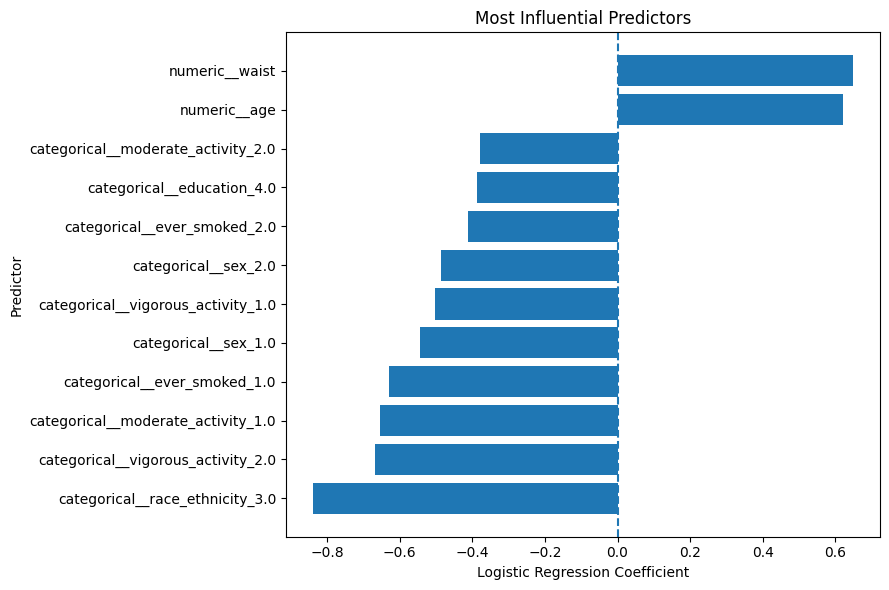

In [39]:
lr_model = models["Logistic Regression"]

feature_names = (
    lr_model
    .named_steps["prep"]
    .get_feature_names_out()
)

coefficients = (
    lr_model
    .named_steps["model"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute_Effect"] = (
    coef_df["Coefficient"].abs()
)

top_features = (
    coef_df
    .sort_values("Absolute_Effect", ascending=False)
    .head(12)
    .sort_values("Coefficient")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Predictor")
plt.title("Most Influential Predictors")

plt.tight_layout()
plt.show()